In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("1-studyhours.csv")

In [3]:
df.head()

,Study Hours,Exam Score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Study Hours  33 non-null     float64
 1   Exam Score   33 non-null     float64
dtypes: float64(2)
memory usage: 660.0 bytes


In [5]:
df.describe()

,Study Hours,Exam Score
count,33.000000,33.000000
mean,15.772727,74.612121
std,7.608723,18.711206
min,3.000000,40.000000
25%,9.600000,58.500000
50%,17.400000,78.800000
75%,21.300000,90.800000
max,30.000000,100.000000


In [6]:
df.columns

Index(['Study Hours', 'Exam Score'], dtype='str')

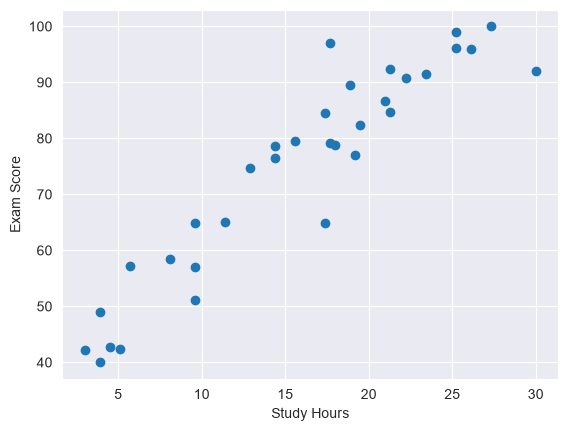

In [7]:
plt.scatter(df["Study Hours"], df["Exam Score"])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.show()

In [8]:
# independent and dependent features
#X -> girdiler df olarak istenir (iki tana kapalı parantez.)
#y -> çıktı series olarak istenir
X = df [["Study Hours"]]
y = df["Exam Score"]

In [9]:
type(X)

pandas.DataFrame

In [10]:
type(y)

pandas.Series

In [11]:
#test-train split
# -> datalarımızı 2 ye bölüp bir kısmını train diğer kısmını test için kullanır.

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
#X_train, X_test ,y_train, y_test

In [14]:
X_train, X_test ,y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [15]:
X_train

,Study Hours
21,8.1
12,30.0
0,3.9
4,14.4
16,5.7
5,18.0
13,27.3
11,26.1
24,9.6
1,9.6


In [16]:
y_train

21     58.5
12     92.0
0      40.0
4      78.7
16     57.2
5      78.8
13    100.0
11     95.9
24     51.2
1      57.1
2      42.7
29     82.4
3      65.1
27     79.5
23     42.2
30     91.5
22     76.5
18     64.9
25     42.4
6      77.1
20     49.0
32     89.6
7      90.8
10     92.4
14     86.6
28     79.1
Name: Exam Score, dtype: float64

In [17]:
y_test

31    96.2
15    97.0
26    64.8
17    74.7
8     99.0
9     84.6
19    84.7
Name: Exam Score, dtype: float64

In [18]:
#standardize the data set -> kolonlar arasındaki ilişkiyi tekdüze indirmek için -1 ve 1 arasına koymak gibi. ayrıca bu outlier yani istisna olan değerler için de çok değerlidir.

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
df.head()

,Study Hours,Exam Score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7


In [21]:
# balanced feature values
# efficient gradient descent
# l1,l2

In [22]:
scaler = StandardScaler()

In [23]:
X_train

,Study Hours
21,8.1
12,30.0
0,3.9
4,14.4
16,5.7
5,18.0
13,27.3
11,26.1
24,9.6
1,9.6


In [24]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
#fit -> ortalamayı bul #transform -> küçült
#test zaten biz ona dönüştürmeye çalışıyoruz trainlerimizi o yüzden fit etmiyoruz

In [25]:
X_train

array([[-0.89166498],
       [ 1.91959769],
       [-1.43081124],
       [-0.08294558],
       [-1.19974856],
       [ 0.37917979],
       [ 1.57300366],
       [ 1.41896187],
       [-0.69911274],
       [-0.69911274],
       [-1.35379035],
       [ 0.57173203],
       [-0.46805005],
       [ 0.07109621],
       [-1.54634258],
       [ 1.07236785],
       [-0.08294558],
       [ 0.3021589 ],
       [-1.27676945],
       [ 0.53322158],
       [-1.43081124],
       [ 0.49471113],
       [ 0.91832606],
       [ 0.80279471],
       [ 0.76428427],
       [ 0.34066934]])

In [26]:
X_test

array([[ 1.30343053],
       [ 0.34066934],
       [-0.69911274],
       [-0.27549782],
       [ 1.30343053],
       [ 0.3021589 ],
       [ 0.80279471]])

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
regression = LinearRegression()

In [52]:
regression.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[17.77]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,71.58
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[5.1]


In [53]:
print("Coefficients: \n", regression.coef_)
print("Intercept: \n", regression.intercept_)

Coefficients: 
 [17.77325513]
Intercept: 
 71.58461538461538


In [54]:
# y = 71.58 + 17.77x

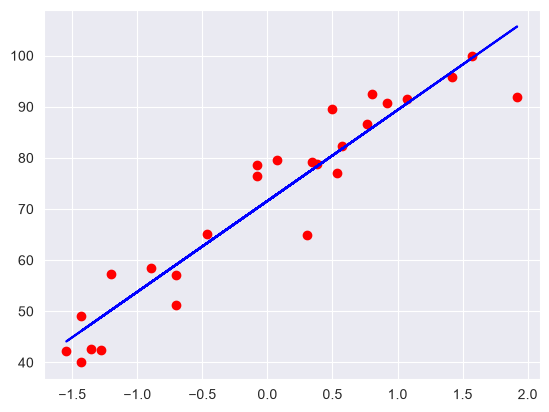

In [55]:
plt.scatter(X_train, y_train, color = "red")
plt.plot(X_train, regression.predict(X_train), color = "blue")

In [56]:

#x = 20 , y = ?

In [57]:
regression.predict([[20]])

array([427.04971807])

In [58]:
scaler.transform([[20]])

C:\Users\busra\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.63591611]])

In [59]:
regression.predict(scaler.transform([[20]]))

C:\Users\busra\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([82.8869146])

In [60]:
regression.predict(scaler.transform([[10]]))


C:\Users\busra\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([60.07171432])

In [61]:
regression.predict(scaler.transform([[0]]))

C:\Users\busra\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([37.25651403])

In [62]:
# prediction with test data

In [63]:
y_pred_test = regression.predict(X_test)

In [64]:
y_test

31    96.2
15    97.0
26    64.8
17    74.7
8     99.0
9     84.6
19    84.7
Name: Exam Score, dtype: float64

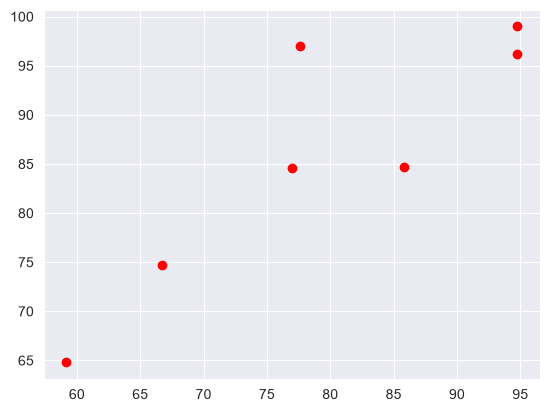

In [65]:
plt.scatter(y_pred_test, y_test, c = "red")
plt.show()

In [66]:
from  sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [67]:
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)

In [68]:
print("mse: ", mse)
print("mae: ", mae)
print("rmse: ", rmse)

mse:  78.68191446465701
mae:  6.7870919092666515
rmse:  8.870282659794839


In [69]:
r2 = r2_score(y_test, y_pred_test)
print("r2: ", r2)

r2:  0.4349170848122318


In [70]:
#adjusted R2 squared
1 - (1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.3219005017746781